In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
import requests
import pandas as pd
import json
import time
import numpy as np
from datetime import datetime
from homeharvest import scrape_property
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import mean_absolute_percentage_error
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import seaborn as sns 

for dirname, _, filenames in os.walk("./"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 1. Frame the problem
Using the customer description, Define the problem your trying to solve in your own words (remember this is not technial but must be specific so the customer understands the project

We must build an Machine player that can play the tetris and win, or play for as long as possible without loosing. Loosing is defined reaching the top of the board and theres either no more space for the block to go or the block is placed over causing it to overflow. 

# 2. Get the Data 
Define how you recieved the data (provided, gathered..)

In [2]:
# The plan is to use a genetic model, so model is trained at the same time as gathered data
import numpy as np
import random
from copy import deepcopy

# --- Hyperparameters ---
POP_SIZE = 50
NUM_FEATURES = 9
NOISE_SD = 0.2
MUTATION_RATE = 0.1
NUM_GENERATIONS = 20

def initialize_population(pop_size, num_features):
    """Generates the initial population data (list of random weight arrays)."""
    # The 'population' is a list of N=POP_SIZE genotype arrays (the data)
    population = [np.random.uniform(-1, 1, num_features) for _ in range(pop_size)]
    return population

In [3]:
from game import Game
from genetic import Genetic_AI
import sys
import os
from contextlib import contextmanager
import multiprocessing
# from game import Game 
# from genetic import Genetic_AI # Needed for the agent logic
# import numpy as np # Needed for array handling
# ... include all other necessary imports

# --- Utility to Silence Prints ---
@contextmanager
def suppress_output():
    """Temporarily redirects stdout to /dev/null to suppress prints."""
    original_stdout = sys.stdout
    with open(os.devnull, 'w') as f:
        sys.stdout = f
        try:
            yield
        finally:
            sys.stdout = original_stdout

# --- Updated Data Gathering Function ---
def run_game_simulation(genotype):
    """
    Instantiates the Genetic_AI agent, runs the simulation, and silences 
    the verbose print statements from Game.run_no_visual().
    """
    
    # 1. Instantiate the AI agent
    ai_agent = Genetic_AI(genotype=genotype)
    
    # 2. Instantiate the Game class
    g = Game(mode="genetic", agent=ai_agent)
    
    # 3. Run the simulation and SILENCE THE OUTPUT
    with suppress_output():
        # This call will be silent
        results_tuple = g.run_no_visual()
    
    # 4. Extract the fitness score (rows cleared)
    rows_cleared = results_tuple[1]
    
    return rows_cleared

def evaluate_population(population):
    """
    Gathers the fitness scores in parallel using all available CPU cores.
    """
    
    # Passing None to Pool uses os.cpu_count() for maximum parallelism
    with multiprocessing.Pool(None) as pool: 
        
        # 'pool.map' runs run_game_simulation on every item in 'population' concurrently
        fitness_scores = pool.map(run_game_simulation, population)
    
    return fitness_scores

pygame 2.6.1 (SDL 2.28.4, Python 3.12.6)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [4]:
# Used in earlier cells but this is part of the Model Data Step
def crossover(gene_a, gene_b):
    """Single-point crossover for two genotype arrays."""
    split_point = random.randint(1, len(gene_a) - 1)
    child_gene = np.concatenate((gene_a[:split_point], gene_b[split_point:]))
    return child_gene

def mutate(genotype, noise_sd):
    """Applies Gaussian mutation to a genotype array."""
    mutation = np.array([np.random.normal(1, noise_sd) for _ in range(len(genotype))])
    return genotype * mutation

def select_and_reproduce(population, scores, pop_size, mutation_rate, noise_sd):
    """Selects the best, mates them, and creates the next population."""
    
    # 1. Combine data (genotype and score) and sort for selection
    scored_population = list(zip(population, scores))
    scored_population.sort(key=lambda x: x[1], reverse=True)
    
    # Keep the top half as parents (Elitism/Selection)
    num_parents = pop_size // 2
    parents = [item[0] for item in scored_population[:num_parents]]
    new_population = deepcopy(parents) # Start with elites

    # 2. Reproduce until population size is reached (Crossover/Mutation)
    while len(new_population) < pop_size:
        parent_a = random.choice(parents)
        parent_b = random.choice(parents)
        
        # Crossover
        child_genotype = crossover(parent_a, parent_b)
        
        # Mutation
        if random.random() < mutation_rate:
            child_genotype = mutate(child_genotype, noise_sd)
        
        new_population.append(child_genotype)
        
    return new_population

In [10]:
# Initialize Population (Generation 0 Data)
current_population = initialize_population(POP_SIZE, NUM_FEATURES)
history = {'max_fitness': [], 'avg_fitness': []}
    
print(f"Starting GA Training for {NUM_GENERATIONS} generations...")

for gen in range(NUM_GENERATIONS):
    print(f"\n--- Generation {gen} ---")
        
    # 1. DATA GATHERING
    scores = evaluate_population(current_population)
        
    # Data Exploration (Summary)
    max_score = np.max(scores)
    avg_score = np.mean(scores)
    history['max_fitness'].append(max_score)
    history['avg_fitness'].append(avg_score)
        
    print(f"Max Score: {max_score:.2f}, Avg Score: {avg_score:.2f}")

    # 2. TRAINING (Evolution)
    if gen < NUM_GENERATIONS - 1:
        current_population = select_and_reproduce(
            current_population, scores, POP_SIZE, MUTATION_RATE, NOISE_SD
        )
            
# Find the best overall genotype from the final population
final_scores = evaluate_population(current_population)
best_genotype = current_population[np.argmax(final_scores)]
print("\n--- Training Complete ---")
print(f"Final Best Genotype: {best_genotype}")

Starting GA Training for 20 generations...

--- Generation 0 ---
Max Score: 489.00, Avg Score: 11.54

--- Generation 1 ---
Max Score: 98.00, Avg Score: 3.66

--- Generation 2 ---
Max Score: 210.00, Avg Score: 13.36

--- Generation 3 ---
Max Score: 310.00, Avg Score: 23.70

--- Generation 4 ---
Max Score: 302.00, Avg Score: 41.84

--- Generation 5 ---
Max Score: 685.00, Avg Score: 85.36

--- Generation 6 ---
Max Score: 715.00, Avg Score: 97.16

--- Generation 7 ---
Max Score: 424.00, Avg Score: 105.70

--- Generation 8 ---
Max Score: 597.00, Avg Score: 146.00

--- Generation 9 ---
Max Score: 718.00, Avg Score: 133.40

--- Generation 10 ---
Max Score: 499.00, Avg Score: 159.46

--- Generation 11 ---
Max Score: 604.00, Avg Score: 138.66

--- Generation 12 ---
Max Score: 533.00, Avg Score: 150.62

--- Generation 13 ---
Max Score: 2334.00, Avg Score: 227.84

--- Generation 14 ---
Max Score: 758.00, Avg Score: 183.76

--- Generation 15 ---
Max Score: 1301.00, Avg Score: 267.46

--- Generatio

In [26]:
# A manually created genotype that should CLEARLY favor good moves:
# (Assuming index 0 is rows_cleared and index 1 is aggregate_height)
test_genotype = np.array([1.0, -0.8, -0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
from game import Game 
import numpy as np

test_genotype = np.array([1.0, -0.8, -0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

try:
    g = Game(test_genotype) 
    final_score = g.run_no_visual()
    print(f"Test Game Score: {final_score}")
except Exception as e:
    print(f"Game crashed! Error: {e}")

Game crashed! Error: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()


# 3. Explore the Data
Gain insights into the data you have from step 2, making sure to identify any bias

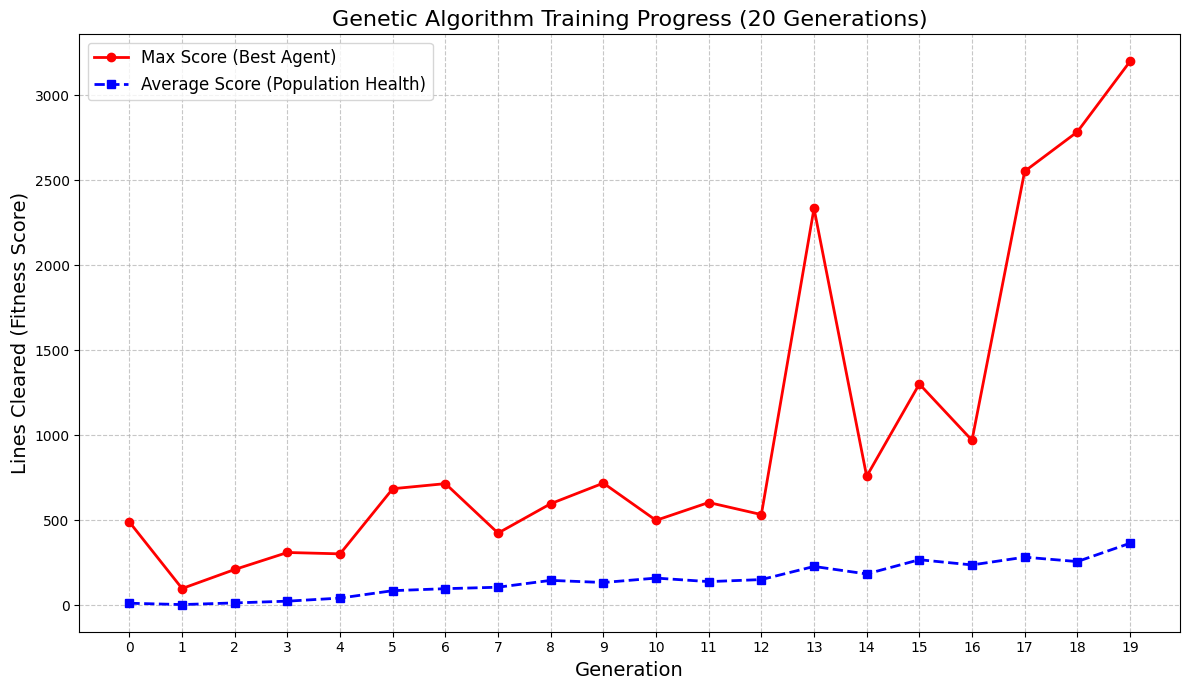

In [5]:
import matplotlib.pyplot as plt
history = {
    'max_score': [
        489.00, 98.00, 210.00, 310.00, 302.00, 685.00, 715.00, 424.00,
        597.00, 718.00, 499.00, 604.00, 533.00, 2334.00, 758.00, 1301.00,
        970.00, 2552.00, 2784.00, 3198.00
    ],
    'avg_score': [
        11.54, 3.66, 13.36, 23.70, 41.84, 85.36, 97.16, 105.70,
        146.00, 133.40, 159.46, 138.66, 150.62, 227.84, 183.76, 267.46,
        236.80, 282.54, 256.60, 364.18
    ]
}

generations = range(len(history['max_score']))

# --- Plotting the Results ---
plt.figure(figsize=(12, 7))

# Plot the Max Score 
plt.plot(generations, history['max_score'], 
         label='Max Score (Best Agent)', 
         marker='o', 
         linestyle='-', 
         color='red',
         linewidth=2)

# Plot the Average Score
plt.plot(generations, history['avg_score'], 
         label='Average Score (Population Health)', 
         marker='s', 
         linestyle='--', 
         color='blue',
         linewidth=2)

plt.title('Genetic Algorithm Training Progress (20 Generations)', fontsize=16)
plt.xlabel('Generation', fontsize=14)
plt.ylabel('Lines Cleared (Fitness Score)', fontsize=14)
plt.xticks(generations)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Max spikes are increasing very fast but the average is lagging behind. Increase selection pressure in select_and_reproduce()

# 4.Prepare the Data


Apply any data transformations and explain what and why


In [ ]:
# Increase "selection" of the data, meaning more of the higher ranges of data are going to be selected to carry on to next generations

In [6]:
import random
from copy import deepcopy
import numpy as np 


def select_and_reproduce(population, scores, pop_size, mutation_rate, noise_sd):
    scored_population = list(zip(population, scores))
    scored_population.sort(key=lambda x: x[1], reverse=True)
    
    num_parents = pop_size // 4  # Top 25% make it through
    
    parents = [item[0] for item in scored_population[:num_parents]]
    new_population = deepcopy(parents)  # Elitism: Copy the top 25% directly
    weights = list(range(len(parents), 0, -1))
    while len(new_population) < pop_size:
        
        # Better score is higher chance
        parent_a = random.choices(parents, weights=weights, k=1)[0]
        parent_b = random.choices(parents, weights=weights, k=1)[0]
        child_genotype = crossover(parent_a, parent_b)
        if random.random() < mutation_rate:
            child_genotype = mutate(child_genotype, noise_sd)
        
        new_population.append(child_genotype)
        
    return new_population

# 5. Model the data
Using selected ML models, experment with your choices and describe your findings. Finish by selecting a Model to continue with


In [7]:
POP_SIZE = 50
NUM_FEATURES = 9
NOISE_SD = 0.2
MUTATION_RATE = 0.1
NUM_GENERATIONS = 20

    
print(f"Starting GA Training for {NUM_GENERATIONS} generations...")

current_population = initialize_population(POP_SIZE, NUM_FEATURES)
history = {'max_fitness': [], 'avg_fitness': []}


for gen in range(NUM_GENERATIONS):
    print(f"\n--- Generation {gen} ---")
        
    # 1. DATA GATHERING
    scores = evaluate_population(current_population)
        
    # Data Exploration (Summary)
    max_score = np.max(scores)
    avg_score = np.mean(scores)
    history['max_fitness'].append(max_score)
    history['avg_fitness'].append(avg_score)
        
    print(f"Max Score: {max_score:.2f}, Avg Score: {avg_score:.2f}")

    # 2. TRAINING (Evolution)
    if gen < NUM_GENERATIONS - 1:
        current_population = select_and_reproduce(
            current_population, scores, POP_SIZE, MUTATION_RATE, NOISE_SD
        )
            
# Find the best overall genotype from the final population
final_scores = evaluate_population(current_population)
best_genotype = current_population[np.argmax(final_scores)]
print("\n--- Training Complete ---")
print(f"Final Best Genotype: {best_genotype}")

Starting GA Training for 20 generations...

--- Generation 0 ---
Max Score: 5.00, Avg Score: 0.28

--- Generation 1 ---
Max Score: 86.00, Avg Score: 3.40

--- Generation 2 ---
Max Score: 361.00, Avg Score: 35.84

--- Generation 3 ---
Max Score: 950.00, Avg Score: 144.02

--- Generation 4 ---
Max Score: 1240.00, Avg Score: 287.24

--- Generation 5 ---
Max Score: 1785.00, Avg Score: 564.72

--- Generation 6 ---
Max Score: 1474.00, Avg Score: 434.30

--- Generation 7 ---
Max Score: 1780.00, Avg Score: 455.56

--- Generation 8 ---
Max Score: 2724.00, Avg Score: 520.96

--- Generation 9 ---
Max Score: 2451.00, Avg Score: 547.46

--- Generation 10 ---
Max Score: 4277.00, Avg Score: 582.02

--- Generation 11 ---
Max Score: 4528.00, Avg Score: 634.68

--- Generation 12 ---
Max Score: 6222.00, Avg Score: 1074.66

--- Generation 13 ---
Max Score: 8299.00, Avg Score: 1393.42

--- Generation 14 ---
Max Score: 7891.00, Avg Score: 1589.24

--- Generation 15 ---
Max Score: 10758.00, Avg Score: 2034.1

# 6. Fine Tune the Model

With the select model descibe the steps taken to acheve the best rusults possiable 


In [8]:
import numpy as np

# Your final evolved weights (Genotype)
FINAL_BEST_GENOTYPE = np.array([0.49803886, 0.33523575, -0.12441215, 0.67174152, -0.14066038, -0.40435825, -0.16559478, -0.5419739, -0.32272779])

In [9]:
ai_agent = Genetic_AI(genotype=FINAL_BEST_GENOTYPE)
print("Starting Visual Run of the Final Best Agent (Max Score: ~10,000+ potential)")
print("Note: The visual speed is much slower than the training speed.")
game = Game(mode="visual_ai", agent=ai_agent) 
game.run() # Result unfortunately occured many many times, meaning it must have exploited certain features

Starting Visual Run of the Final Best Agent (Max Score: ~10,000+ potential)
Note: The visual speed is much slower than the training speed.


error: XDG_RUNTIME_DIR not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


Pieces dropped: 9
Rows cleared: 0


(9, 0)

# 7. Present
In a customer faceing Document provide summery of finding and detail approach taken


# 8. Launch the Model System
Define your production run code, This should be self susficent and require only your model pramaters 


In [ ]:
def inference(params):
    results = params
    return results
    